# Flow and isochron rotation around asymmetric bed obstacles

This notebook tests whether a static bedrock obstacle can create folds from initially horizontal material layers. The calculation is a baseline for the first part of the mechanical hypothesis in the README: obstacle size, symmetry, orientation, and sign are varied while the ice rheology and background flow are held fixed.

Waddington, Bolzan, and Alley (2001) found that small smooth symmetric bed undulations produce small standing waves rather than stratigraphic overturning. Here the largest obstacle is 80 m high or deep, one-half of the 160 m reference ice thickness. Its compact-cosine flanks reach 68°. No initial layer slope is imposed: each material line begins horizontal on the flat bed upstream of the obstacle.

## Model and fold criterion

The 800 m periodic domain contains one fixed obstacle. At each time, velocity and pressure satisfy the incompressible Full-Stokes equations with isotropic Glen $n=3$ rheology,

$$
-\nabla\cdot\boldsymbol\sigma=\rho\mathbf g,
\qquad \nabla\cdot\mathbf u=0,
\qquad
\boldsymbol\sigma=2\eta\dot{\boldsymbol\varepsilon}-p\mathbf I.
$$

The bed is no-slip, the upper boundary is traction-free, and surface mass balance is zero. The free surface evolves according to

$$
\frac{\partial h}{\partial t}=w_s-u_s\frac{\partial h}{\partial x}.
$$

The mesh is rebuilt from an immutable vertical reference coordinate after every surface update. This avoids cumulative mesh distortion but does not remap the Lagrangian particles. The time step is at most 500 yr and is reduced to limit the surface Courant number, surface displacement, and deformation-gradient increment.

Along every particle path, the deformation-gradient tensor is integrated from $\mathbf F(0)=\mathbf I$ using

$$
\frac{\mathrm d\mathbf F}{\mathrm dt}=\nabla\mathbf u\,\mathbf F.
$$

An initially horizontal material tangent is $\mathbf t_0=(1,0)$. Its current orientation is $\mathbf t=\mathbf F\mathbf t_0$. A fold is counted only when $t_x$ changes sign: the tangent must pass through vertical and overturn. Layer relief or a large but subvertical dip is not classified as a fold.

In [1]:
import logging
import warnings

warnings.filterwarnings("ignore", message="Unable to import recommended hash")
import firedrake as fd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

logging.getLogger("tsfc").setLevel(logging.ERROR)

L, H = 800.0, 160.0
NX, NZ = 48, 10
RHO, GRAVITY, SURFACE_SLOPE = 917.0, 9.81, 0.03
REFERENCE_VISCOSITY = 2.5e8  # Pa yr
STRAIN_FLOOR = 1.0e-10        # yr^-1
FINAL_TIME, DT_MAX = 25_000.0, 500.0

CASES = [
    {
        "name": "small symmetric bump",
        "short": "small sym. bump",
        "amplitude": 16.0,
        "width_left": 100.0,
        "width_right": 100.0,
    },
    {
        "name": "large symmetric bump",
        "short": "large sym. bump",
        "amplitude": 80.0,
        "width_left": 100.0,
        "width_right": 100.0,
    },
    {
        "name": "large asymmetric bump, steep upstream",
        "short": "asym. bump, steep up",
        "amplitude": 80.0,
        "width_left": 50.0,
        "width_right": 150.0,
    },
    {
        "name": "large asymmetric bump, gentle upstream",
        "short": "asym. bump, gentle up",
        "amplitude": 80.0,
        "width_left": 150.0,
        "width_right": 50.0,
    },
    {
        "name": "large asymmetric pit, steep upstream",
        "short": "asym. pit, steep up",
        "amplitude": -80.0,
        "width_left": 50.0,
        "width_right": 150.0,
    },
]

driving_stress_gradient = RHO * GRAVITY * np.sin(SURFACE_SLOPE)
reference_surface_speed = (
    driving_stress_gradient * H**2 / (2 * REFERENCE_VISCOSITY)
)
print(f"Reference surface speed: {reference_surface_speed:.4f} m/yr")
print(f"Mesh: {NX} x {NZ}; maximum time step: {DT_MAX:.0f} yr")

Reference surface speed: 0.0138 m/yr
Mesh: 48 x 10; maximum time step: 500 yr


## Controlled geometries

The obstacle center is at $x=400$ m. On each side, the bed is one-half of a cosine from zero to the stated amplitude. The profile and its first derivative are continuous at the obstacle top and feet. Positive amplitude makes a convex bump and negative amplitude makes a concave pit. The two asymmetric bumps differ only in their orientation relative to flow.

In [2]:
def bed_profile(x, amplitude, width_left, width_right):
    distance = (np.asarray(x) - 0.5 * L + 0.5 * L) % L - 0.5 * L
    bed = np.zeros_like(distance, dtype=float)
    left = (distance >= -width_left) & (distance <= 0)
    right = (distance > 0) & (distance <= width_right)
    bed[left] = 0.5 * amplitude * (
        1 + np.cos(np.pi * distance[left] / width_left)
    )
    bed[right] = 0.5 * amplitude * (
        1 + np.cos(np.pi * distance[right] / width_right)
    )
    return bed


case_table = []
for case in CASES:
    steepest_width = min(case["width_left"], case["width_right"])
    maximum_slope = abs(case["amplitude"]) * np.pi / (2 * steepest_width)
    case_table.append(
        {
            "case": case["name"],
            "amplitude / H": case["amplitude"] / H,
            "upstream half-width (m)": case["width_left"],
            "downstream half-width (m)": case["width_right"],
            "maximum bed slope (deg)": np.degrees(np.arctan(maximum_slope)),
        }
    )
display(pd.DataFrame(case_table).round(2))

,case,amplitude / H,upstream half-width (m),downstream half-width (m),maximum bed slope (deg)
0,small symmetric bump,0.1,100.0,100.0,14.11
1,large symmetric bump,0.5,100.0,100.0,51.49
2,"large asymmetric bump, steep upstream",0.5,50.0,150.0,68.30
3,"large asymmetric bump, gentle upstream",0.5,150.0,50.0,68.30
4,"large asymmetric pit, steep upstream",-0.5,50.0,150.0,68.30


## Transient Full-Stokes calculation

Nine open material lines begin 5--120 m upstream of the obstacle foot at elevations 7, 10, 15, 20, 30, 50, 90, 120, and 140 m. The lowest four correspond to initial core depths of 140--153 m over the flat bed. This upstream construction is important: using layers that already conform to the obstacle would impose the disturbance that the calculation is intended to explain.

A linear-to-nonlinear rheology continuation initializes each case. If a later Newton solve fails, the continuation is repeated at the same geometry and time. The accepted solution is always Glen $n=3$; the restart changes only the nonlinear initial guess.

In [3]:
def run_case(case):
    amplitude = case["amplitude"]
    width_left = case["width_left"]
    width_right = case["width_right"]

    mesh = fd.PeriodicRectangleMesh(NX, NZ, L, H, direction="x")
    reference = mesh.coordinates.dat.data_ro.copy()
    reference_x = reference[:, 0].copy()
    sigma_coordinate = reference[:, 1] / H
    x_surface = np.linspace(0.0, L, NX, endpoint=False)
    surface = np.full(NX, H)
    bed_nodes = bed_profile(reference_x, amplitude, width_left, width_right)

    def periodic_interpolate(points, values):
        return np.interp(
            np.mod(points, L),
            np.r_[x_surface, L],
            np.r_[values, values[0]],
        )

    def update_mesh():
        top_nodes = periodic_interpolate(reference_x, surface)
        mesh.coordinates.dat.data[:, 0] = reference_x
        mesh.coordinates.dat.data[:, 1] = (
            bed_nodes + sigma_coordinate * (top_nodes - bed_nodes)
        )
        mesh.clear_spatial_index()

    update_mesh()
    velocity_space = fd.VectorFunctionSpace(mesh, "CG", 2)
    pressure_space = fd.FunctionSpace(mesh, "CG", 1)
    mixed_space = velocity_space * pressure_space
    solution = fd.Function(mixed_space, name="velocity_pressure")
    velocity_symbol, pressure_symbol = fd.split(solution)
    test_velocity, test_pressure = fd.TestFunctions(mixed_space)
    body_force = fd.Constant(
        (
            RHO * GRAVITY * np.sin(SURFACE_SLOPE),
            -RHO * GRAVITY * np.cos(SURFACE_SLOPE),
        )
    )

    def residual(exponent):
        softness = reference_surface_speed * (exponent + 1) / (
            2
            * driving_stress_gradient**exponent
            * H ** (exponent + 1)
        )
        strain_rate = fd.sym(fd.grad(velocity_symbol))
        effective_strain_rate = fd.sqrt(
            0.5 * fd.inner(strain_rate, strain_rate) + STRAIN_FLOOR**2
        )
        viscosity = (
            0.5
            * softness ** (-1 / exponent)
            * effective_strain_rate ** ((1 - exponent) / exponent)
        )
        return (
            2
            * viscosity
            * fd.inner(strain_rate, fd.sym(fd.grad(test_velocity)))
            - pressure_symbol * fd.div(test_velocity)
            - test_pressure * fd.div(velocity_symbol)
            - fd.dot(body_force, test_velocity)
        ) * fd.dx

    residuals = {n: residual(n) for n in (1.0, 2.0, 3.0)}
    bed_boundary = fd.DirichletBC(
        mixed_space.sub(0), fd.Constant((0.0, 0.0)), 1
    )
    solver_parameters = {
        "snes_type": "newtonls",
        "snes_linesearch_type": "bt",
        "snes_rtol": 1.0e-8,
        "snes_max_it": 100,
        "ksp_type": "preonly",
        "pc_type": "lu",
        "pc_factor_mat_solver_type": "mumps",
    }
    z_symbol = fd.SpatialCoordinate(mesh)[1]
    velocity, pressure = solution.subfunctions

    def reset_guess():
        solution.sub(0).interpolate(fd.Constant((0.005, 0.0)))
        solution.sub(1).interpolate(
            RHO
            * GRAVITY
            * np.cos(SURFACE_SLOPE)
            * (H - z_symbol)
        )

    def solve_with_continuation():
        reset_guess()
        for exponent in (1.0, 2.0, 3.0):
            fd.solve(
                residuals[exponent] == 0,
                solution,
                bcs=[bed_boundary],
                solver_parameters=solver_parameters,
            )
            pressure.dat.data[:] -= np.mean(pressure.dat.data_ro)

    solve_with_continuation()
    tensor_space = fd.TensorFunctionSpace(mesh, "DG", 1)
    velocity_gradient = fd.Function(tensor_space)

    layer_heights = np.array(
        [7.0, 10.0, 15.0, 20.0, 30.0, 50.0, 90.0, 120.0, 140.0]
    )
    particles_per_layer = 64
    obstacle_foot = 0.5 * L - width_left
    initial_line_x = np.linspace(
        obstacle_foot - 120.0,
        obstacle_foot - 5.0,
        particles_per_layer,
    )
    initial_x = np.tile(initial_line_x, len(layer_heights))
    initial_z = np.repeat(layer_heights, particles_per_layer)
    particle_x = initial_x.copy()
    particle_z = initial_z.copy()
    particle_count = len(particle_x)

    deformation = np.tile(np.eye(2), (particle_count, 1, 1))
    initial_tangent = np.zeros((particle_count, 2))
    initial_tangent[:, 0] = 1.0
    ever_overturned = np.zeros(particle_count, dtype=bool)
    first_overturn = np.full(particle_count, np.nan)
    maximum_dip_particle = np.zeros(particle_count)

    cumulative_G = np.zeros(particle_count)
    cumulative_D = np.zeros(particle_count)
    times = [0.0]
    maximum_dip_history = [0.0]
    target_dip_history = [0.0]
    overturned_history = [0]
    angle_history = [np.zeros(particle_count)]
    G_history = [np.zeros(particle_count)]
    D_history = [np.zeros(particle_count)]
    cumulative_G_history = [cumulative_G.copy()]
    cumulative_D_history = [cumulative_D.copy()]
    surface_relief_history = [0.0]
    volume_error_history = [0.0]

    bed_surface_grid = bed_profile(
        x_surface, amplitude, width_left, width_right
    )
    initial_volume = L * np.mean(surface - bed_surface_grid)
    time = 0.0
    step = 0
    restart_count = 0
    while time < FINAL_TIME - 1.0e-9:
        if step > 0:
            update_mesh()
            try:
                fd.solve(
                    residuals[3.0] == 0,
                    solution,
                    bcs=[bed_boundary],
                    solver_parameters=solver_parameters,
                )
                pressure.dat.data[:] -= np.mean(pressure.dat.data_ro)
            except fd.ConvergenceError:
                solve_with_continuation()
                restart_count += 1

        velocity_gradient.interpolate(fd.grad(velocity))

        x_evaluation = x_surface.copy()
        x_evaluation[0] = 1.0e-5
        top_evaluation = periodic_interpolate(x_evaluation, surface)
        surface_points = np.column_stack(
            (x_evaluation, top_evaluation - 1.0e-4)
        )
        surface_velocity = np.asarray(
            velocity.at(surface_points, tolerance=1.0e-7)
        )
        dx_surface = L / NX
        surface_slope = (
            np.roll(surface, -1) - np.roll(surface, 1)
        ) / (2 * dx_surface)
        surface_rate = (
            surface_velocity[:, 1]
            - surface_velocity[:, 0] * surface_slope
        )

        particle_evaluation_x = np.mod(particle_x, L)
        particle_evaluation_x[
            np.isclose(particle_evaluation_x, 0.0)
        ] = 1.0e-5
        particle_points = np.column_stack(
            (particle_evaluation_x, particle_z)
        )
        particle_velocity = np.asarray(
            velocity.at(particle_points, tolerance=1.0e-7)
        )
        gradient_values = np.asarray(
            velocity_gradient.at(particle_points, tolerance=1.0e-7)
        )

        gradient_norm = np.max(
            np.linalg.norm(gradient_values, axis=(1, 2))
        )
        dt = min(
            DT_MAX,
            0.4
            * dx_surface
            / max(np.max(np.abs(surface_velocity[:, 0])), 1.0e-12),
            1.0 / max(np.max(np.abs(surface_rate)), 1.0e-12),
            0.15 / max(gradient_norm, 1.0e-12),
            FINAL_TIME - time,
        )

        tangent_before = np.einsum(
            "nij,nj->ni", deformation, initial_tangent
        )
        deformation += dt * np.einsum(
            "nij,njk->nik", gradient_values, deformation
        )
        tangent_after = np.einsum(
            "nij,nj->ni", deformation, initial_tangent
        )
        new_crossing = (
            (tangent_before[:, 0] > 0)
            & (tangent_after[:, 0] <= 0)
            & np.isnan(first_overturn)
        )
        crossing_fraction = np.divide(
            tangent_before[:, 0],
            tangent_before[:, 0] - tangent_after[:, 0],
            out=np.zeros(particle_count),
            where=new_crossing,
        )
        first_overturn[new_crossing] = (
            time + crossing_fraction[new_crossing] * dt
        )
        ever_overturned |= tangent_after[:, 0] < 0
        angle = np.degrees(
            np.arctan2(np.abs(tangent_after[:, 1]), tangent_after[:, 0])
        )
        maximum_dip_particle = np.maximum(maximum_dip_particle, angle)

        G = gradient_values[:, 0, 1] + gradient_values[:, 1, 0]
        D = gradient_values[:, 0, 0] - gradient_values[:, 1, 1]
        cumulative_G += dt * G
        cumulative_D += dt * D

        surface += dt * surface_rate
        particle_x += dt * particle_velocity[:, 0]
        particle_z += dt * particle_velocity[:, 1]
        time += dt
        step += 1

        volume = L * np.mean(surface - bed_surface_grid)
        volume_error = volume / initial_volume - 1
        target = slice(0, 4 * particles_per_layer)
        times.append(time)
        maximum_dip_history.append(np.max(angle))
        target_dip_history.append(np.max(angle[target]))
        overturned_history.append(np.count_nonzero(ever_overturned))
        angle_history.append(angle.copy())
        G_history.append(G.copy())
        D_history.append(D.copy())
        cumulative_G_history.append(cumulative_G.copy())
        cumulative_D_history.append(cumulative_D.copy())
        surface_relief_history.append(np.ptp(surface))
        volume_error_history.append(volume_error)

    # Re-solve once on the final regenerated mesh for field plots.
    update_mesh()
    try:
        fd.solve(
            residuals[3.0] == 0,
            solution,
            bcs=[bed_boundary],
            solver_parameters=solver_parameters,
        )
        pressure.dat.data[:] -= np.mean(pressure.dat.data_ro)
    except fd.ConvergenceError:
        solve_with_continuation()
        restart_count += 1
    velocity_gradient.interpolate(fd.grad(velocity))

    x_query = np.linspace(L / 160, L - L / 160, 80)
    sigma_query = np.linspace(0.02, 0.98, 32)
    # Sample between the piecewise-linear boundaries actually used
    # by the finite-element mesh, rather than the analytic bed.
    bed_query = periodic_interpolate(x_query, bed_surface_grid)
    surface_query = periodic_interpolate(x_query, surface)
    X_query = np.tile(x_query, (len(sigma_query), 1))
    Z_query = bed_query[None, :] + sigma_query[:, None] * (
        surface_query - bed_query
    )[None, :]
    query_points = np.column_stack((X_query.ravel(), Z_query.ravel()))
    velocity_values = np.asarray(
        velocity.at(query_points, tolerance=1.0e-7)
    ).reshape(Z_query.shape + (2,))
    gradient_grid = np.asarray(
        velocity_gradient.at(query_points, tolerance=1.0e-7)
    ).reshape(Z_query.shape + (2, 2))
    G_grid = gradient_grid[..., 0, 1] + gradient_grid[..., 1, 0]
    D_grid = gradient_grid[..., 0, 0] - gradient_grid[..., 1, 1]
    S_grid = np.divide(
        G_grid,
        D_grid,
        out=np.full_like(G_grid, np.nan),
        where=np.abs(D_grid) >= 1.0e-7,
    )

    layer_metrics = []
    for layer_index, height in enumerate(layer_heights):
        selected = slice(
            layer_index * particles_per_layer,
            (layer_index + 1) * particles_per_layer,
        )
        layer_metrics.append(
            {
                "initial z (m)": height,
                "initial core depth (m)": H - height,
                "maximum dip (deg)": np.max(
                    maximum_dip_particle[selected]
                ),
                "overturned particles": np.count_nonzero(
                    ever_overturned[selected]
                ),
                "first overturn (yr)": (
                    np.nanmin(first_overturn[selected])
                    if np.any(np.isfinite(first_overturn[selected]))
                    else np.nan
                ),
            }
        )

    target_indices = np.arange(4 * particles_per_layer)
    representative = target_indices[
        np.argmax(maximum_dip_particle[target_indices])
    ]
    times_array = np.asarray(times)
    angle_array = np.asarray(angle_history)
    G_array = np.asarray(G_history)
    D_array = np.asarray(D_history)
    cumulative_G_array = np.asarray(cumulative_G_history)
    cumulative_D_array = np.asarray(cumulative_D_history)
    S_representative = np.divide(
        G_array[:, representative],
        D_array[:, representative],
        out=np.full_like(G_array[:, representative], np.nan),
        where=np.abs(D_array[:, representative]) >= 1.0e-7,
    )

    final_bed_at_particles = periodic_interpolate(
        particle_x, bed_surface_grid
    )
    return {
        "case": case,
        "steps": step,
        "restarts": restart_count,
        "times": times_array,
        "max_dip_history": np.asarray(maximum_dip_history),
        "target_dip_history": np.asarray(target_dip_history),
        "overturned_history": np.asarray(overturned_history),
        "surface_relief_history": np.asarray(surface_relief_history),
        "volume_error_history": np.asarray(volume_error_history),
        "surface": surface.copy(),
        "x_surface": x_surface.copy(),
        "initial_x": initial_x,
        "initial_z": initial_z,
        "particle_x": particle_x,
        "particle_z": particle_z,
        "layer_heights": layer_heights,
        "particles_per_layer": particles_per_layer,
        "layer_metrics": pd.DataFrame(layer_metrics),
        "maximum_dip": np.max(maximum_dip_particle),
        "target_maximum_dip": np.max(
            maximum_dip_particle[target_indices]
        ),
        "overturned": int(np.count_nonzero(ever_overturned)),
        "first_overturn": (
            np.nanmin(first_overturn)
            if np.any(np.isfinite(first_overturn))
            else np.nan
        ),
        "maximum_volume_error": np.max(
            np.abs(volume_error_history)
        ),
        "minimum_bed_clearance": np.min(
            particle_z - final_bed_at_particles
        ),
        "maximum_horizontal_displacement": np.max(
            particle_x - initial_x
        ),
        "representative_angle": angle_array[:, representative],
        "representative_G": G_array[:, representative],
        "representative_D": D_array[:, representative],
        "representative_S": S_representative,
        "representative_cumulative_G": cumulative_G_array[
            :, representative
        ],
        "representative_cumulative_D": cumulative_D_array[
            :, representative
        ],
        "X_query": X_query,
        "Z_query": Z_query,
        "velocity_grid": velocity_values,
        "S_grid": S_grid,
    }

In [4]:
results = []
for case in CASES:
    print(f"Running {case['name']} ...", flush=True)
    result = run_case(case)
    results.append(result)
    print(
        f"  {result['steps']} steps; target maximum dip "
        f"{result['target_maximum_dip']:.1f} degrees; "
        f"{result['overturned']} overturned particles; "
        f"volume residual {result['maximum_volume_error']:.2e}",
        flush=True,
    )

Running small symmetric bump ...


  52 steps; target maximum dip 8.0 degrees; 0 overturned particles; volume residual 1.16e-06


Running large symmetric bump ...


  51 steps; target maximum dip 2.8 degrees; 0 overturned particles; volume residual 5.16e-05


Running large asymmetric bump, steep upstream ...


  51 steps; target maximum dip 4.4 degrees; 0 overturned particles; volume residual 4.73e-05


Running large asymmetric bump, gentle upstream ...


  51 steps; target maximum dip 2.1 degrees; 0 overturned particles; volume residual 5.58e-05


Running large asymmetric pit, steep upstream ...


  83 steps; target maximum dip 33.8 degrees; 0 overturned particles; volume residual 1.07e-06


## Fold test

The table reports the most rotated tangent among the four initially basal layers. “Overturned” is an exact sign test on the integrated tangent. The minimum bed clearance verifies that the explicit particle update leaves every tracked layer inside the ice.

In [5]:
summary = pd.DataFrame(
    [
        {
            "case": result["case"]["name"],
            "target maximum dip (deg)": result["target_maximum_dip"],
            "all-layer maximum dip (deg)": result["maximum_dip"],
            "overturned particles": result["overturned"],
            "first overturn (yr)": result["first_overturn"],
            "surface relief at 25 ka (m)": result[
                "surface_relief_history"
            ][-1],
            "maximum volume residual": result["maximum_volume_error"],
            "minimum bed clearance (m)": result[
                "minimum_bed_clearance"
            ],
            "maximum particle travel (m)": result[
                "maximum_horizontal_displacement"
            ],
            "nonlinear restarts": result["restarts"],
        }
        for result in results
    ]
)
display(summary.round(3))

if summary["overturned particles"].sum() == 0:
    print("Result: no initially horizontal material tangent overturns in any case.")
else:
    print(
        "Result: at least one case produces a fold; see the first-overturn times above."
    )

,case,target maximum dip (deg),all-layer maximum dip (deg),overturned particles,first overturn (yr),surface relief at 25 ka (m),maximum volume residual,minimum bed clearance (m),maximum particle travel (m),nonlinear restarts
0,small symmetric bump,7.953,7.953,0,NaN,2.323,0.0,6.797,323.086,0
1,large symmetric bump,2.770,16.232,0,NaN,9.159,0.0,7.200,155.176,0
2,"large asymmetric bump, steep upstream",4.351,43.878,0,NaN,9.147,0.0,7.059,155.390,0
3,"large asymmetric bump, gentle upstream",2.136,8.840,0,NaN,9.197,0.0,7.134,137.329,0
4,"large asymmetric pit, steep upstream",33.833,33.833,0,NaN,2.219,0.0,4.506,361.341,0


Result: no initially horizontal material tangent overturns in any case.


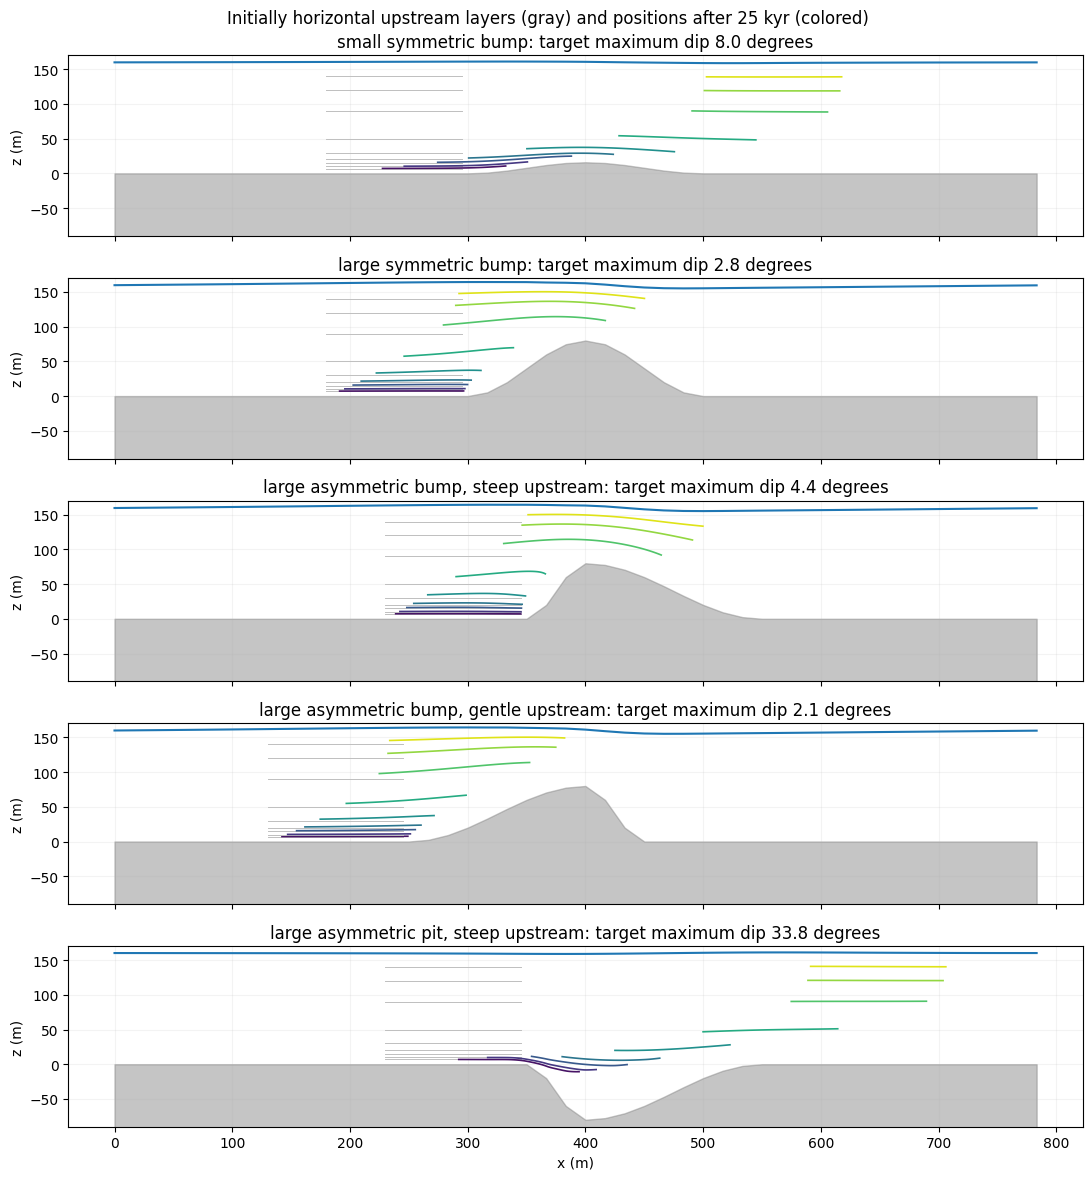

In [6]:
fig, axes = plt.subplots(len(results), 1, figsize=(11, 12), sharex=True)
colors = plt.cm.viridis(np.linspace(0.05, 0.95, 9))
for axis, result in zip(axes, results):
    case = result["case"]
    bed = bed_profile(
        result["x_surface"],
        case["amplitude"],
        case["width_left"],
        case["width_right"],
    )
    axis.fill_between(
        result["x_surface"], -100, bed, color="0.5", alpha=0.45
    )
    axis.plot(
        result["x_surface"], result["surface"], color="tab:blue", lw=1.5
    )
    for layer, color in enumerate(colors):
        selected = slice(
            layer * result["particles_per_layer"],
            (layer + 1) * result["particles_per_layer"],
        )
        axis.plot(
            result["initial_x"][selected],
            result["initial_z"][selected],
            color="0.75",
            lw=0.7,
        )
        axis.plot(
            result["particle_x"][selected],
            result["particle_z"][selected],
            color=color,
            lw=1.2,
        )
    axis.set_ylim(-90, 170)
    axis.set_ylabel("z (m)")
    axis.set_title(
        f"{case['name']}: target maximum dip "
        f"{result['target_maximum_dip']:.1f} degrees"
    )
    axis.grid(alpha=0.15)
axes[-1].set_xlabel("x (m)")
fig.suptitle(
    "Initially horizontal upstream layers (gray) and positions after 25 kyr (colored)"
)
fig.tight_layout()
plt.show()

## Flow and WBA fields

The left column shows final vertical velocity, with velocity arrows rescaled independently in each panel so their direction remains visible. The right column shows the Waddington--Bolzan--Alley shear parameter

$$
S=\frac{G}{D},\qquad
G=\frac{\partial u}{\partial z}+\frac{\partial w}{\partial x},
\qquad
D=\frac{\partial u}{\partial x}-\frac{\partial w}{\partial z}.
$$

$S$ is masked where $|D|<10^{-7}$ yr$^{-1}$ and clipped to $\pm10$ for plotting. This diagnostic does not enter the flow solution or tangent integration.

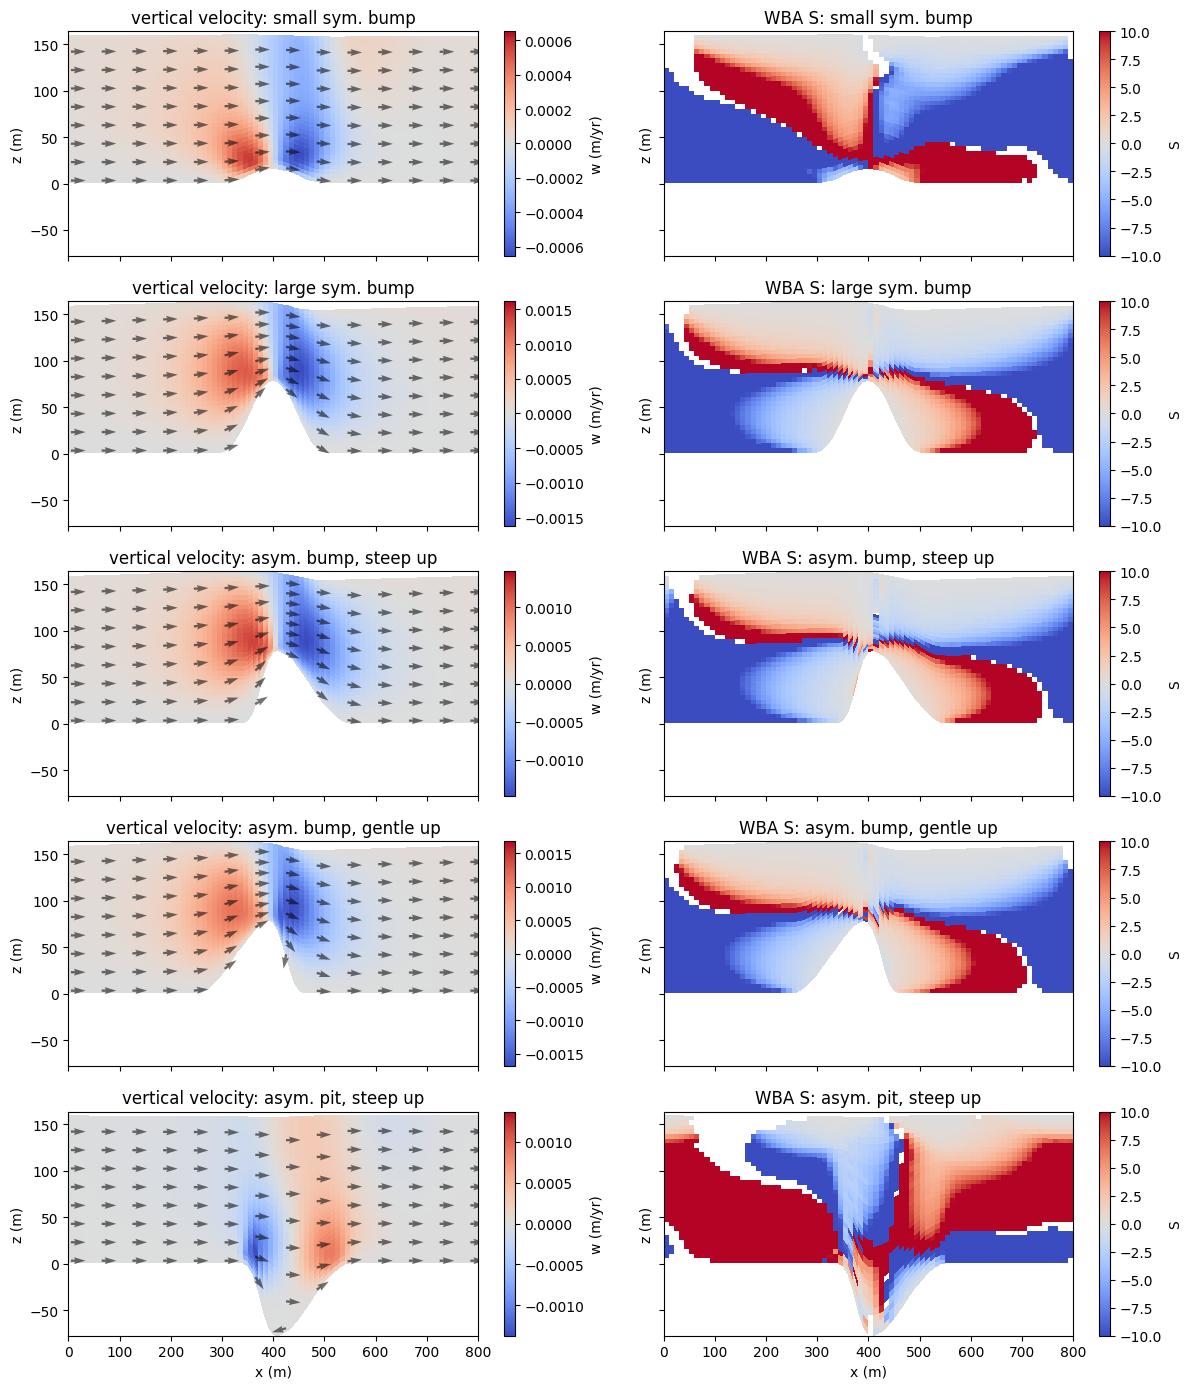

In [7]:
fig, axes = plt.subplots(len(results), 2, figsize=(12, 14), sharex=True, sharey=True)
for row, result in enumerate(results):
    X = result["X_query"]
    Z = result["Z_query"]
    velocity_grid = result["velocity_grid"]
    vertical_velocity = velocity_grid[..., 1]
    S_grid = np.clip(result["S_grid"], -10, 10)

    vertical_scale = np.nanmax(np.abs(vertical_velocity))
    image_w = axes[row, 0].pcolormesh(
        X,
        Z,
        vertical_velocity,
        shading="auto",
        cmap="coolwarm",
        vmin=-vertical_scale,
        vmax=vertical_scale,
    )
    stride_x, stride_z = 6, 4
    arrows_u = velocity_grid[::stride_z, ::stride_x, 0]
    arrows_w = velocity_grid[::stride_z, ::stride_x, 1]
    arrow_scale = np.sqrt(arrows_u**2 + arrows_w**2)
    arrows_u = arrows_u / np.maximum(arrow_scale, 1.0e-12)
    arrows_w = arrows_w / np.maximum(arrow_scale, 1.0e-12)
    axes[row, 0].quiver(
        X[::stride_z, ::stride_x],
        Z[::stride_z, ::stride_x],
        arrows_u,
        arrows_w,
        color="k",
        alpha=0.55,
        scale=28,
    )
    fig.colorbar(image_w, ax=axes[row, 0], label="w (m/yr)")

    image_S = axes[row, 1].pcolormesh(
        X,
        Z,
        S_grid,
        shading="auto",
        cmap="coolwarm",
        vmin=-10,
        vmax=10,
    )
    fig.colorbar(image_S, ax=axes[row, 1], label="S")
    for column in range(2):
        axes[row, column].set_ylabel("z (m)")
        axes[row, column].set_title(
            ("vertical velocity: " if column == 0 else "WBA S: ")
            + result["case"]["short"]
        )
axes[-1, 0].set_xlabel("x (m)")
axes[-1, 1].set_xlabel("x (m)")
fig.tight_layout()
plt.show()

## Finite-strain histories

For each case, the representative path is the initially basal particle that reaches the largest dip. The first panel is the direct fold test. The second compares accumulated simple-shear numerator $G$ with accumulated pure-shear denominator $D$. The third shows the local ratio $S$ only where its denominator is resolved.

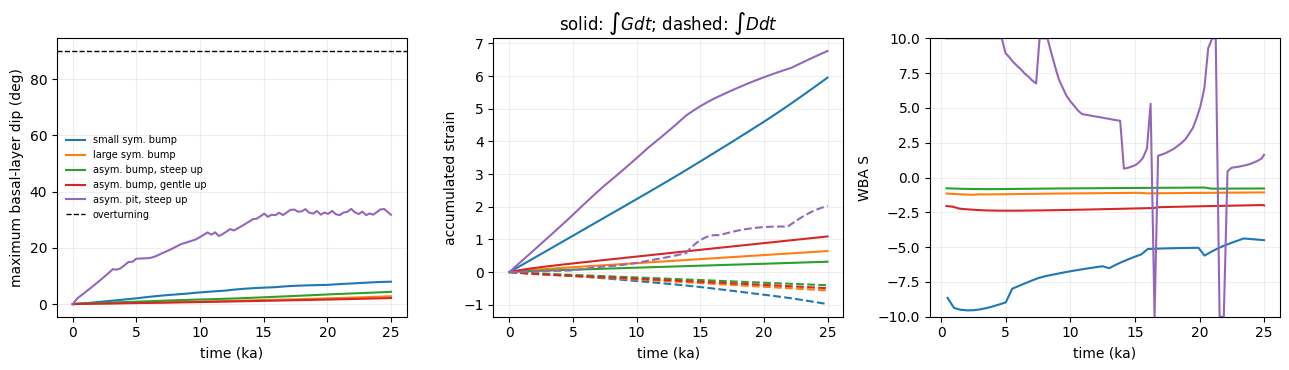

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
case_colors = plt.cm.tab10(np.arange(len(results)))
for color, result in zip(case_colors, results):
    time_ka = result["times"] / 1000
    label = result["case"]["short"]
    axes[0].plot(time_ka, result["target_dip_history"], color=color, label=label)
    axes[1].plot(
        time_ka,
        result["representative_cumulative_G"],
        color=color,
        label=label,
    )
    axes[1].plot(
        time_ka,
        result["representative_cumulative_D"],
        color=color,
        ls="--",
    )
    axes[2].plot(
        time_ka,
        np.clip(result["representative_S"], -10, 10),
        color=color,
    )

axes[0].axhline(90, color="k", ls="--", lw=1, label="overturning")
axes[0].set(xlabel="time (ka)", ylabel="maximum basal-layer dip (deg)")
axes[0].legend(frameon=False, fontsize=7)
axes[1].set(
    xlabel="time (ka)",
    ylabel="accumulated strain",
    title="solid: $\int Gdt$; dashed: $\int Ddt$",
)
axes[2].set(xlabel="time (ka)", ylabel="WBA S", ylim=(-10, 10))
for axis in axes:
    axis.grid(alpha=0.2)
fig.tight_layout()
plt.show()

## Interpretation

None of the five static obstacles overturns an initially horizontal upstream layer within 25 kyr. At the ALHIC1901 target depths, the asymmetric pit produces the largest dip, 33.8°. The small symmetric bump reaches 8.0°, whereas the large symmetric and asymmetric bumps reach only 2.1--4.4° because the basal particles slow against the obstacle. The large convex obstacles deform higher layers more strongly: the all-layer maximum is 16.2° for the symmetric bump, 43.9° when the asymmetric bump has its steep face upstream, and 8.8° when the same bump is reversed. Thus size, sign, and orientation all matter, but breaking symmetry is not sufficient for a fold in this baseline Glen-flow calculation.

This result is narrower than the earlier scouting calculation in which layers were initialized parallel to the bed. Those layers began with steep tangents and did overturn, but that initialization imposed the structure at issue. The upstream-horizontal calculation reported here requires the obstacle to generate all layer slope and is therefore the relevant test.

The calculation does not rule out static topography generally. It tests one background slope, one flow speed, compact obstacles with 50--150 m flank widths, and 25 kyr of deformation. Within that stated scope, static obstacle flow does not produce an ALHIC1901 fold and does not explain the Shackleton et al. observation.